# Cross-layer EDA 06: Drug and tumour validation

This notebook remains **exploratory data analysis**. It investigates whether current external data can provide supporting validation for measured gene-pair routes without fitting a prediction model.

## Drug questions

1. Do genetic dependency on Gene B and sensitivity to drugs annotated as targeting Gene B move together?
2. Are cells with a molecular state in Gene A more sensitive to drugs targeting Gene B?
3. Are cell lines carrying a direct fusion more sensitive to drugs targeting either fusion partner?

The local PRISM file is the historical primary repurposing screen: cell viability after chemical perturbation, reported as replicate-collapsed log2 fold-change relative to control. Lower values mean a larger viability reduction and therefore greater sensitivity. The screen and its limitations are described by the [DepMap PRISM Repurposing release](https://depmap.org/portal/data_page/?release=PRISM+Repurposing+19Q4&tab=allData) and [Corsello et al.](https://pubmed.ncbi.nlm.nih.gov/32613204/).

## Tumour questions

1. Which TCGA disease cohorts could eventually test cell-line findings in patient tumours?
2. Which molecular tumour layers are actually present locally?
3. What must still be added before tumour validation is possible?

## Guardrails

- Use direct `model_id` matches only for PRISM-to-DepMap model joins.
- Keep PRISM 19Q4 and DepMap 24Q4 release provenance visible.
- Treat a drug's annotated targets as mechanism metadata, not proof of complete selectivity.
- Keep individual treatments visible; treatments targeting the same gene are not independent replicates.
- Use lineage-adjusted comparisons and exact denominators.
- Lower PRISM log2 fold-change and lower CRISPR gene effect both mean stronger loss of viability.
- Never join a TCGA patient to a cell line. Tumour-project mapping is cohort context, not identity matching.
- Do not claim tumour validation from clinical metadata alone.
- Do not train, rank, weight, or calibrate gene pairs in this notebook.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

pd.set_option('display.max_columns', 180)
pd.set_option('display.max_rows', 180)
sns.set_theme(style='whitegrid', context='notebook')


def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'data' / 'depmap_24Q4' / 'architecture' / 'model_master.csv').exists():
            return candidate
    raise FileNotFoundError('Run this notebook from inside the az-team25 repository.')


def canonical_pair(gene_a: str, gene_b: str) -> str:
    return '--'.join(sorted([str(gene_a).upper(), str(gene_b).upper()]))


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
CORE = PROJECT_ROOT / 'data' / 'depmap_24Q4'
EXT = PROJECT_ROOT / 'data' / 'external'
PATHS = {
    'master': CORE / 'architecture' / 'model_master.csv',
    'gene_master': CORE / 'architecture' / 'gene_master.csv',
    'fusion_pairs': CORE / 'architecture' / 'fusion_pair_evidence.csv',
    'effect': CORE / 'raw' / 'CRISPRGeneEffect.csv',
    'mutations': CORE / 'derived' / 'mutations_default_dna_gene_summary.csv',
    'copy_number': CORE / 'raw' / 'OmicsAbsoluteCNGene.csv',
    'prism_response': EXT / 'prism_repurposing' / 'raw' / 'primary-screen-replicate-collapsed-logfold-change.csv',
    'prism_treatments': EXT / 'prism_repurposing' / 'derived' / 'prism_treatment_catalog.csv',
    'prism_cells': EXT / 'prism_repurposing' / 'derived' / 'prism_cell_line_catalog.csv',
    'prism_schema': EXT / 'prism_repurposing' / 'derived' / 'prism_response_matrix_schema.json',
    'tcga': EXT / 'tcga_gdc' / 'derived' / 'tcga_patient_master.csv',
}

master = pd.read_csv(PATHS['master'], low_memory=False)
gene_master = pd.read_csv(PATHS['gene_master'], low_memory=False)
fusion_calls = pd.read_csv(PATHS['fusion_pairs'], low_memory=False)
mutations = pd.read_csv(PATHS['mutations'], low_memory=False)
prism_treatments = pd.read_csv(PATHS['prism_treatments'], low_memory=False)
prism_cells = pd.read_csv(PATHS['prism_cells'], low_memory=False)
tcga = pd.read_csv(PATHS['tcga'], low_memory=False)

assert master['model_id'].is_unique
assert gene_master['symbol'].is_unique
master['oncotree_lineage'] = master['oncotree_lineage'].fillna('Unknown')
lineage_lookup = master.set_index('model_id')['oncotree_lineage']
gene_lookup = gene_master.set_index('symbol')

print(f'DepMap 24Q4 models: {len(master):,}')
print(f'PRISM treatment records: {len(prism_treatments):,}')
print(f'PRISM cell catalogue rows: {len(prism_cells):,}')
print(f'TCGA clinical patients: {tcga.patient_id.nunique():,}')

DepMap 24Q4 models: 2,105
PRISM treatment records: 4,686
PRISM cell catalogue rows: 588
TCGA clinical patients: 11,428


## Column dictionary

| Column | Meaning | Project use |
|---|---|---|
| `model_id` | Stable DepMap cell-line identifier. | Only automatic model-level join key between PRISM and DepMap. |
| `treatment_id` | PRISM matrix column name combining compound identifier, dose, and screen. | Exact chemical perturbation identity. |
| `broad_id` | Broad compound sample identifier. | Compound provenance; one name can have multiple identifiers. |
| `drug_name` | Human-readable treatment name. | Dashboard label. |
| `dose`, `screen_id` | Tested concentration and primary-screen batch. | Assay context; primary screening is not a full dose-response experiment. |
| `annotated_targets` | Comma-separated PRISM treatment targets. | Connects a chemical perturbation to a candidate Gene B. |
| `n_annotated_targets` | Number of target genes listed for the treatment. | Selectivity warning for multi-target compounds. |
| `prism_log2_fold_change` | Log2 viability change relative to control. | Lower values mean greater drug sensitivity. |
| `prism_models` | Models with a non-missing response for the treatment. | Drug-response denominator. |
| `shared_crispr_prism_models` | Models with both PRISM response and Gene B CRISPR effect. | Genetic-to-chemical comparison denominator. |
| `lineage_adjusted_genetic_drug_rho` | Spearman correlation after subtracting lineage medians from both assays. | Positive means genetically sensitive models also tend to be chemically sensitive. |
| `directional_pair_id` | Molecular-context hypothesis in `Gene A -> Gene B` order. | Preserves conditional direction. |
| `context_type` | Damaging mutation or copy-number loss. | Keeps biological mechanisms separate. |
| `context_models`, `reference_models` | PRISM models in the molecular-context and comparison groups. | Exact conditional drug-response denominators. |
| `lineage_adjusted_drug_sensitivity_shift` | Reference median residual response minus context median residual response. | Positive means context cells are more sensitive to the targeted treatment. |
| `fusion_positive_models` | PRISM models with a retained DepMap fusion call for the exact pair. | Direct-fusion drug-response numerator. |
| `lineage_matched_reference_models` | Fusion-negative PRISM models from lineages represented by the fusion-positive group. | Disease-aware comparison group. |
| `tcga_project_id` | TCGA disease project, such as `TCGA-BRCA`. | Patient-tumour cohort identity. |
| `mapped_oncotree_lineage` | Explicit broad mapping from a TCGA project to a DepMap lineage. | Cohort comparison only; never a patient-to-cell-line join. |
| `tumour_validation_state` | Whether clinical and required molecular tumour layers are present. | Prevents clinical metadata from being mistaken for molecular validation. |

## 1. PRISM matrix grain, orientation, and model join audit

The response CSV has cell lines in rows and treatment conditions in columns. The existing local schema JSON describes the orientation incorrectly, so this notebook derives and asserts the grain from the actual row identifiers, treatment catalogue, and matrix headers.

,matrix_rows_cell_lines,matrix_columns_treatments,catalogue_treatments,matrix_columns_matching_catalogue,direct_model_id_matches,unmatched_matrix_rows,shared_crispr_prism_models,observed_response_cells,response_matrix_observed_pct
0,578,4686,4686,4686,568,10,469,2632171,97.181585


,prism_row_id,contains_failed_str_flag
0,ACH-000010_FAILED_STR,True
1,ACH-000028_FAILED_STR,True
2,ACH-000409_FAILED_STR,True
3,ACH-000460_FAILED_STR,True
4,ACH-000511_FAILED_STR,True
5,ACH-000539_FAILED_STR,True
6,ACH-000807_FAILED_STR,True
7,ACH-000925_FAILED_STR,True
8,ACH-000992_FAILED_STR,True
9,ACH-001078_FAILED_STR,True


,prism_log2_fold_change
count,2.632171e+06
mean,-2.232124e-01
std,8.813850e-01
min,-7.775048e+00
1%,-4.135838e+00
5%,-1.869875e+00
25%,-4.021086e-01
50%,-4.884946e-02
75%,2.359695e-01
95%,6.702232e-01


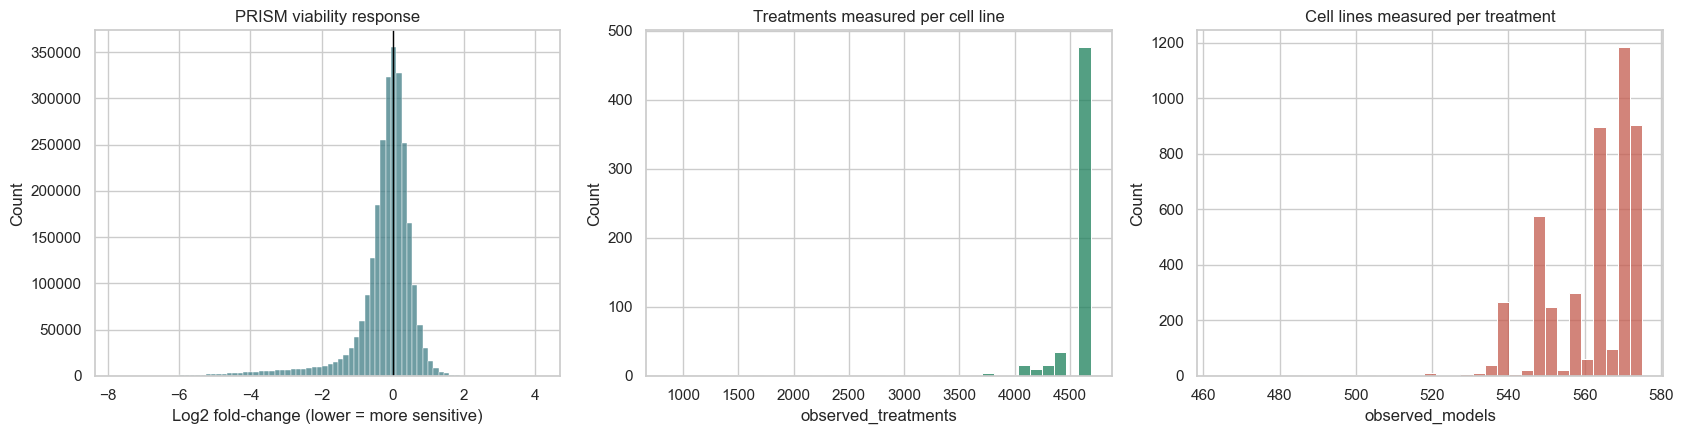

In [2]:
prism_response = pd.read_csv(PATHS['prism_response'], low_memory=False).rename(columns={'Unnamed: 0': 'prism_row_id'}).set_index('prism_row_id')
matrix_treatments = set(prism_response.columns)
catalog_treatments = set(prism_treatments['column_name'])
master_ids = set(master['model_id'])
crispr_ids = set(master.loc[master['has_crispr_gene_effect'].eq(1), 'model_id'])

direct_model_ids = sorted(set(prism_response.index) & master_ids)
unmatched_prism_rows = sorted(set(prism_response.index) - master_ids)
shared_crispr_prism_ids = sorted(set(direct_model_ids) & crispr_ids)

matrix_values = prism_response.to_numpy(dtype=float)
observed = np.isfinite(matrix_values)
prism_audit = pd.DataFrame([{
    'matrix_rows_cell_lines': prism_response.shape[0],
    'matrix_columns_treatments': prism_response.shape[1],
    'catalogue_treatments': len(prism_treatments),
    'matrix_columns_matching_catalogue': len(matrix_treatments & catalog_treatments),
    'direct_model_id_matches': len(direct_model_ids),
    'unmatched_matrix_rows': len(unmatched_prism_rows),
    'shared_crispr_prism_models': len(shared_crispr_prism_ids),
    'observed_response_cells': int(observed.sum()),
    'response_matrix_observed_pct': 100 * observed.mean(),
}])
display(prism_audit)

unmatched_audit = pd.DataFrame({'prism_row_id': unmatched_prism_rows})
unmatched_audit['contains_failed_str_flag'] = unmatched_audit['prism_row_id'].str.contains('FAILED_STR', case=False, na=False)
display(unmatched_audit)

response_distribution = pd.Series(matrix_values.ravel(), name='prism_log2_fold_change').describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
).to_frame()
display(response_distribution)

row_coverage = pd.Series(observed.sum(axis=1), index=prism_response.index, name='observed_treatments')
column_coverage = pd.Series(observed.sum(axis=0), index=prism_response.columns, name='observed_models')
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
sns.histplot(pd.Series(matrix_values.ravel()).dropna(), bins=80, color='#3f7c85', ax=axes[0])
axes[0].axvline(0, color='black', linewidth=1); axes[0].set_title('PRISM viability response')
axes[0].set_xlabel('Log2 fold-change (lower = more sensitive)')
sns.histplot(row_coverage, bins=35, color='#1b7f5a', ax=axes[1]); axes[1].set_title('Treatments measured per cell line')
sns.histplot(column_coverage, bins=35, color='#c45b4d', ax=axes[2]); axes[2].set_title('Cell lines measured per treatment')
plt.tight_layout(); plt.show()

assert matrix_treatments == catalog_treatments
assert all(str(x).startswith('ACH-') for x in prism_response.index)
assert len(direct_model_ids) == 568

### What this means for the project

The usable PRISM object is a `model_id x treatment` matrix, not a treatment-by-cell-line table. Of 578 historical PRISM rows, 568 directly match the 24Q4 model spine and 469 also have released CRISPR gene effect. The unmatched rows are retained in the audit but are not joined by altered names. PRISM and DepMap come from different releases, so all cross-release comparisons are external sensitivity checks rather than training-table features.

## 2. Treatment metadata and target coverage

We split the comma-separated target field into exact gene symbols. A treatment can have no annotated target or several targets. Multi-target compounds remain included but visibly flagged because their response cannot be attributed to one gene with certainty.

,field,missing_rows,missing_pct
0,broad_id,0,0.000000
1,name,1,0.021340
2,dose,0,0.000000
3,screen_id,0,0.000000
4,moa,361,7.703799
5,target,1222,26.077678
6,phase,1,0.021340


,target_gene,treatment_conditions,unique_drug_names,median_dose,multi_target_treatment_pct,example_drugs,targeted_drug_state
0,ABL1,17,17,2.5,100.000000,bafetinib | adenosine-triphosphate | regorafen...,targeted treatments available
19,PARP1,16,15,2.5,50.000000,niraparib | AG-14361 | olaparib | E7449 | 3-am...,targeted treatments available
1,ALK,14,14,2.5,78.571429,PF-06463922 | ceritinib | entrectinib | brigat...,targeted treatments available
4,BRAF,14,13,2.5,57.142857,LGX818 | AZ-628 | dabrafenib | PLX-4720 | rego...,targeted treatments available
15,MAPK1,14,13,2.5,100.000000,isoprenaline | SB-203580 | bisindolylmaleimide...,targeted treatments available
7,CDK4,13,13,2.5,100.000000,ryuvidine | AT-7519 | abemaciclib | ribociclib...,targeted treatments available
21,RAF1,11,10,2.5,100.000000,SB-203580 | AZ-628 | dabrafenib | regorafenib ...,targeted treatments available
17,MDM2,7,7,2.5,42.857143,nutlin-3 | RITA | idasanutlin | AMG-232 | serd...,targeted treatments available
3,BCR,6,6,2.5,100.000000,bafetinib | metatinib | GZD824 | ponatinib | G...,targeted treatments available
11,EZH2,6,5,2.5,0.000000,tazemetostat | GSK2816126 | UNC1999 | EPZ00568...,targeted treatments available


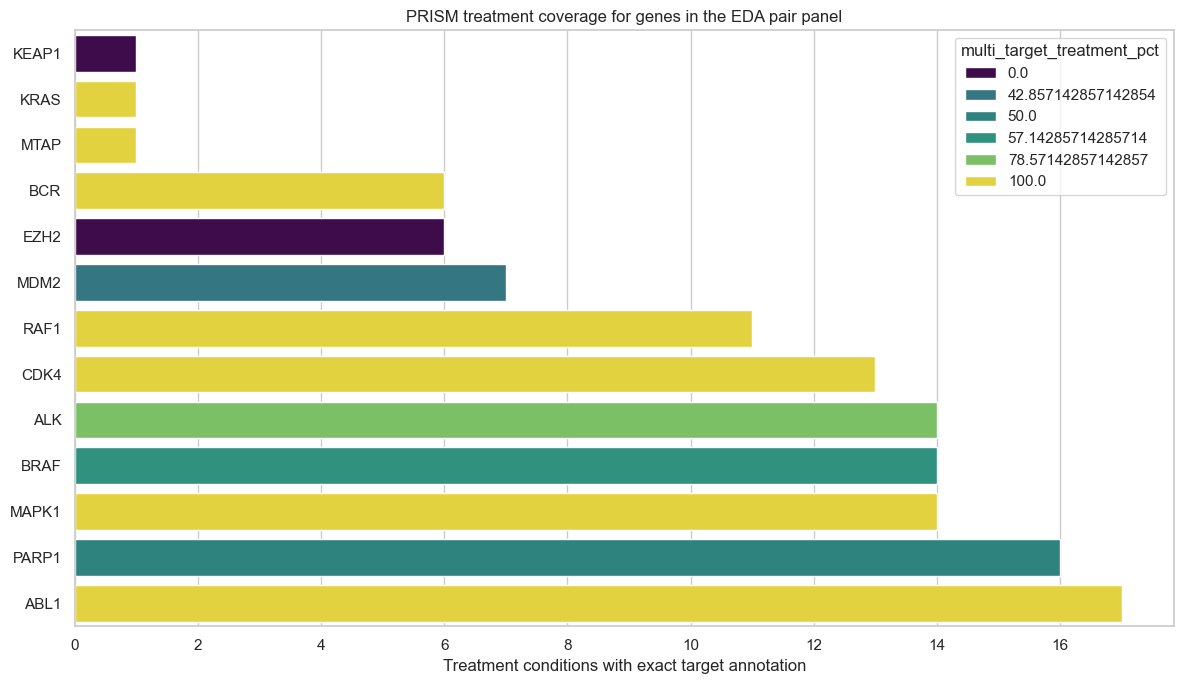

In [3]:
pair_specs = [
    ('BCR', 'ABL1'), ('EML4', 'ALK'), ('TMPRSS2', 'ERG'), ('EWSR1', 'FLI1'),
    ('ARID1A', 'EZH2'), ('SMARCA4', 'SMARCA2'), ('BRCA1', 'PARP1'),
    ('BRCA2', 'PARP1'), ('KRAS', 'RAF1'), ('MTAP', 'PRMT5'), ('MTAP', 'MAT2A'),
    ('BRCA1', 'BRCA2'), ('CDK4', 'MDM2'), ('BRAF', 'MAPK1'), ('STK11', 'KEAP1'),
]
pair_catalog = pd.DataFrame(pair_specs, columns=['input_gene_a', 'input_gene_b'])
pair_catalog['pair_id'] = [canonical_pair(a, b) for a, b in pair_specs]
pair_catalog[['gene_a', 'gene_b']] = pair_catalog['pair_id'].str.split('--', expand=True)
panel_genes = sorted(set(pair_catalog['gene_a']) | set(pair_catalog['gene_b']))

target_long_rows = []
for row in prism_treatments.itertuples(index=False):
    targets = [] if pd.isna(row.target) else [x.strip().upper() for x in str(row.target).split(',') if x.strip()]
    for target in targets:
        target_long_rows.append({
            'treatment_id': row.column_name,
            'broad_id': row.broad_id,
            'drug_name': row.name,
            'dose': row.dose,
            'screen_id': row.screen_id,
            'moa': row.moa,
            'target_gene': target,
            'n_annotated_targets': len(targets),
        })
target_long = pd.DataFrame(target_long_rows)
panel_target_treatments = target_long.loc[target_long['target_gene'].isin(panel_genes)].copy()

target_coverage = pd.DataFrame({'target_gene': panel_genes}).merge(
    panel_target_treatments.groupby('target_gene').agg(
        treatment_conditions=('treatment_id', 'nunique'),
        unique_drug_names=('drug_name', 'nunique'),
        median_dose=('dose', 'median'),
        multi_target_treatment_pct=('n_annotated_targets', lambda s: 100 * s.gt(1).mean()),
        example_drugs=('drug_name', lambda s: ' | '.join(pd.Series(s.dropna().unique()).astype(str).head(8))),
    ).reset_index(),
    on='target_gene', how='left', validate='one_to_one'
)
target_coverage[['treatment_conditions', 'unique_drug_names']] = target_coverage[['treatment_conditions', 'unique_drug_names']].fillna(0).astype(int)
target_coverage['targeted_drug_state'] = np.where(target_coverage['treatment_conditions'].gt(0), 'targeted treatments available', 'no targeted treatment annotation')

treatment_metadata_audit = pd.DataFrame([
    {'field': field, 'missing_rows': int(prism_treatments[field].isna().sum()), 'missing_pct': 100 * prism_treatments[field].isna().mean()}
    for field in ['broad_id', 'name', 'dose', 'screen_id', 'moa', 'target', 'phase']
])
display(treatment_metadata_audit)
display(target_coverage.sort_values('treatment_conditions', ascending=False))

plt.figure(figsize=(12, 7))
plot_targets = target_coverage.loc[target_coverage['treatment_conditions'].gt(0)].sort_values('treatment_conditions')
sns.barplot(data=plot_targets, x='treatment_conditions', y='target_gene', hue='multi_target_treatment_pct', palette='viridis')
plt.title('PRISM treatment coverage for genes in the EDA pair panel')
plt.xlabel('Treatment conditions with exact target annotation'); plt.ylabel('')
plt.tight_layout(); plt.show()

### What this means for the project

Drug validation is possible only for a subset of genes. Targets such as PARP1, ALK, ABL1, BRAF, RAF1, EZH2, CDK4, and MDM2 have annotated PRISM treatments. Other biologically important targets, including SMARCA2, PRMT5, and MAT2A, have no directly annotated treatment in this primary screen. That absence is a coverage limitation, not evidence that they are undruggable. Chemical response is also less gene-specific when a compound has several annotated targets.

## 3. Genetic-to-chemical target concordance

For each panel gene with targeted treatments, we correlate its CRISPR gene-effect profile with each treatment's PRISM response across shared models. Both scales become more negative when viability is reduced, so a positive correlation means genetic and chemical sensitivity tend to occur in the same cell lines. Lineage medians are subtracted from both variables before correlation.

,target_gene,treatment_conditions,median_adjusted_rho,minimum_adjusted_rho,maximum_adjusted_rho,treatments_rho_at_least_0_10,median_shared_models
9,MDM2,7,0.354772,0.031390,0.532694,5,432.0
3,BRAF,14,0.071065,-0.064179,0.127811,2,435.0
10,MTAP,1,0.041866,0.041866,0.041866,0,434.0
11,PARP1,16,0.037073,-0.091325,0.154678,1,431.5
5,EZH2,6,0.033138,0.012748,0.118192,1,435.0
2,BCR,6,0.015391,-0.051695,0.081252,0,445.0
8,MAPK1,14,0.014525,-0.107183,0.117268,3,439.5
6,KEAP1,1,0.011971,0.011971,0.011971,0,433.0
4,CDK4,13,0.008117,-0.107706,0.213395,2,444.0
7,KRAS,1,-0.001175,-0.001175,-0.001175,0,436.0


,target_gene,treatment_id,drug_name,dose,screen_id,n_annotated_targets,shared_crispr_prism_models,lineage_adjusted_models,raw_genetic_drug_rho,lineage_adjusted_genetic_drug_rho
101,MDM2,BRD-K79584249-001-01-3::2.5::HTS,CGM097,2.50,HTS,1,461,434,0.550837,0.532694
87,MDM2,BRD-K64925568-001-01-8::2.5::HTS,AMG-232,2.50,HTS,1,464,446,0.531180,0.521334
83,MDM2,BRD-K62627508-001-01-5::2.5::HTS,idasanutlin,2.50,HTS,2,464,437,0.537299,0.521238
9,MDM2,BRD-A12230535-001-06-7::2.5::HTS,nutlin-3,2.50,HTS,2,444,417,0.373590,0.354772
71,CDK4,BRD-K51313569-003-03-3::2.5::HTS,palbociclib,2.50,HTS,2,464,446,0.175505,0.213395
61,CDK4,BRD-K36788280-001-01-2::2.5::HTS,ribociclib,2.50,HTS,2,461,434,0.177706,0.171739
16,PARP1,BRD-K00615600-001-12-9::2.5::HTS,AG-14361,2.50,HTS,1,438,413,0.161519,0.154678
88,MDM2,BRD-K65924316-001-03-1::2.5::HTS,serdemetan,2.50,HTS,1,459,432,0.116970,0.154593
20,RAF1,BRD-K05804044-001-06-0::2.5::HTS,AZ-628,2.50,HTS,2,464,446,0.160224,0.150161
57,BRAF,BRD-K31866293-001-01-6::2.5::HTS,TAK-632,2.50,HTS,1,462,444,0.285815,0.127811


,target_gene,treatment_id,drug_name,dose,screen_id,n_annotated_targets,shared_crispr_prism_models,lineage_adjusted_models,raw_genetic_drug_rho,lineage_adjusted_genetic_drug_rho
27,RAF1,BRD-K09951645-001-06-8::2.5::HTS,dabrafenib,2.500000,HTS,5,444,417,-0.169900,-0.179640
13,RAF1,BRD-A37704979-001-10-7::2.5::HTS,SB-203580,2.500000,HTS,23,464,446,-0.123083,-0.149834
81,CDK4,BRD-K60997853-001-02-3::2.5::HTS,PHA-848125,2.500000,HTS,4,463,436,-0.095730,-0.107706
12,MAPK1,BRD-A37704979-001-10-7::2.5::HTS,SB-203580,2.500000,HTS,23,464,446,-0.151198,-0.107183
75,ALK,BRD-K56032964-001-02-1::2.5::HTS,AP26113,2.500000,HTS,2,463,436,-0.092389,-0.099437
108,CDK4,BRD-K87909389-003-03-4::2.5::HTS,alvocidib,2.500000,HTS,10,463,445,-0.114732,-0.099147
67,PARP1,BRD-K48692744-001-02-0::2.5::HTS,NU-1025,2.500000,HTS,1,457,432,-0.083149,-0.091325
34,MAPK1,BRD-K16189898-003-03-3::2.5::HTS,CHIR-99021,2.500000,HTS,4,466,448,-0.041487,-0.086391
77,RAF1,BRD-K56343971-001-10-6::2.5::HTS,vemurafenib,2.500000,HTS,2,465,438,-0.125904,-0.082031
74,MAPK1,BRD-K54330070-001-15-4::2.5::HTS,SB-202190,2.500000,HTS,14,461,434,-0.122601,-0.081918


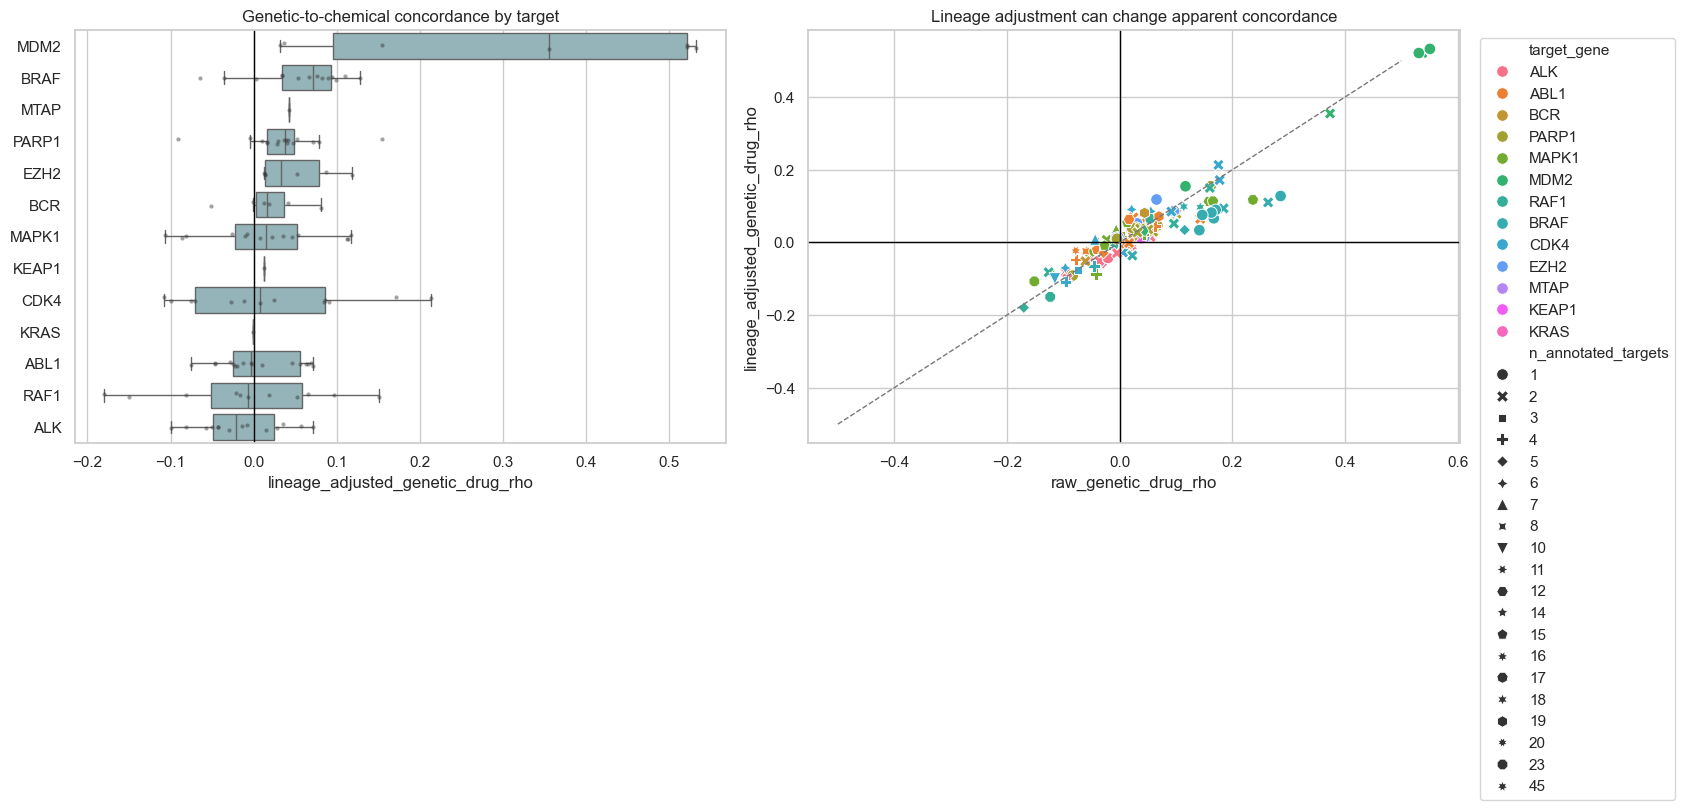

In [4]:
drug_target_genes = sorted(set(panel_target_treatments['target_gene']) & set(gene_lookup.index))
effect_columns = gene_lookup.loc[drug_target_genes, 'crispr_effect_column'].dropna().to_dict()
effect = pd.read_csv(PATHS['effect'], usecols=['Unnamed: 0', *effect_columns.values()]).rename(
    columns={'Unnamed: 0': 'model_id', **{v: k for k, v in effect_columns.items()}}
).set_index('model_id')


def genetic_drug_correlation(target_gene: str, treatment_id: str) -> dict:
    ids = sorted(set(shared_crispr_prism_ids) & set(effect.index))
    frame = pd.DataFrame({
        'gene_effect': effect.loc[ids, target_gene],
        'drug_response': prism_response.loc[ids, treatment_id],
        'lineage': lineage_lookup.reindex(ids),
    }).dropna()
    raw_rho = frame['gene_effect'].corr(frame['drug_response'], method='spearman') if len(frame) >= 30 else np.nan
    keep = frame.groupby('lineage')['gene_effect'].transform('size').ge(10)
    adjusted = frame.loc[keep].copy()
    if len(adjusted) >= 30:
        adjusted[['gene_effect', 'drug_response']] = adjusted[['gene_effect', 'drug_response']] - adjusted.groupby('lineage')[['gene_effect', 'drug_response']].transform('median')
        adjusted_rho = adjusted['gene_effect'].corr(adjusted['drug_response'], method='spearman')
    else:
        adjusted_rho = np.nan
    return {'shared_crispr_prism_models': len(frame), 'lineage_adjusted_models': len(adjusted), 'raw_genetic_drug_rho': raw_rho, 'lineage_adjusted_genetic_drug_rho': adjusted_rho}


concordance_rows = []
for row in panel_target_treatments.itertuples(index=False):
    if row.target_gene not in effect.columns:
        continue
    stats = genetic_drug_correlation(row.target_gene, row.treatment_id)
    concordance_rows.append({
        'target_gene': row.target_gene, 'treatment_id': row.treatment_id,
        'drug_name': row.drug_name, 'dose': row.dose, 'screen_id': row.screen_id,
        'n_annotated_targets': row.n_annotated_targets, **stats,
    })
genetic_drug_concordance = pd.DataFrame(concordance_rows)
concordance_summary = genetic_drug_concordance.groupby('target_gene').agg(
    treatment_conditions=('treatment_id', 'nunique'),
    median_adjusted_rho=('lineage_adjusted_genetic_drug_rho', 'median'),
    minimum_adjusted_rho=('lineage_adjusted_genetic_drug_rho', 'min'),
    maximum_adjusted_rho=('lineage_adjusted_genetic_drug_rho', 'max'),
    treatments_rho_at_least_0_10=('lineage_adjusted_genetic_drug_rho', lambda s: int(s.ge(0.10).sum())),
    median_shared_models=('lineage_adjusted_models', 'median'),
).reset_index()

display(concordance_summary.sort_values('median_adjusted_rho', ascending=False))
display(genetic_drug_concordance.nlargest(30, 'lineage_adjusted_genetic_drug_rho'))
display(genetic_drug_concordance.nsmallest(20, 'lineage_adjusted_genetic_drug_rho'))

fig, axes = plt.subplots(1, 2, figsize=(17, 7))
ordered_targets = concordance_summary.sort_values('median_adjusted_rho', ascending=False)['target_gene']
sns.boxplot(data=genetic_drug_concordance, x='lineage_adjusted_genetic_drug_rho', y='target_gene',
            order=ordered_targets, showfliers=False, color='#8eb8bf', ax=axes[0])
sns.stripplot(data=genetic_drug_concordance, x='lineage_adjusted_genetic_drug_rho', y='target_gene',
              order=ordered_targets, size=3, alpha=0.45, color='#333333', ax=axes[0])
axes[0].axvline(0, color='black', linewidth=1); axes[0].set_title('Genetic-to-chemical concordance by target')
axes[0].set_ylabel('')
sns.scatterplot(data=genetic_drug_concordance, x='raw_genetic_drug_rho', y='lineage_adjusted_genetic_drug_rho',
                hue='target_gene', style='n_annotated_targets', s=70, ax=axes[1])
axes[1].axhline(0, color='black', linewidth=1); axes[1].axvline(0, color='black', linewidth=1)
axes[1].plot([-0.5, 0.5], [-0.5, 0.5], linestyle='--', color='#777777', linewidth=1)
axes[1].set_title('Lineage adjustment can change apparent concordance')
axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout(); plt.show()

### What this means for the project

Genetic-to-chemical concordance asks whether a drug behaves like perturbing its annotated target. Strong positive concordance can support the drug as a useful functional probe. Weak or negative concordance does not automatically disprove the target because drug exposure, dose, off-target activity, incomplete inhibition, and assay timing differ from CRISPR knockout. Treatment-level variation is therefore more informative than replacing all drugs for one gene with a single average.

## 4. Molecular context to targeted-drug response

This section tests predefined directional hypotheses. For example, `BRCA1 -> PARP1` asks whether BRCA1-altered cell lines are more sensitive to treatments annotated as targeting PARP1. Mutation and copy-number loss remain separate. Positive engineered shifts always mean the context group is more drug-sensitive.

,pair_id,directional_pair_id,context_type,target_gene,treatment_records,evaluable_treatments,median_adjusted_sensitivity_shift,minimum_adjusted_sensitivity_shift,maximum_adjusted_sensitivity_shift,treatments_with_positive_shift,median_context_models,median_reference_models,route_states
0,ARID1A--EZH2,ARID1A -> EZH2,Damaging mutation,EZH2,6,6,0.011470,-0.087194,0.078132,3,73.5,451.5,evaluable
1,BRCA1--PARP1,BRCA1 -> PARP1,Damaging mutation,PARP1,16,16,0.081222,-0.144084,0.474570,11,15.0,505.0,evaluable
2,BRCA2--PARP1,BRCA2 -> PARP1,Damaging mutation,PARP1,16,16,0.054909,-0.135647,0.290096,10,19.0,500.5,evaluable
3,KRAS--RAF1,KRAS -> RAF1,Damaging mutation,RAF1,11,11,0.006709,-0.040770,0.170722,7,107.0,415.0,evaluable
4,MAT2A--MTAP,MTAP -> MAT2A,Copy-number loss,MAT2A,0,0,NaN,NaN,NaN,0,0.0,0.0,no_targeted_treatment_annotation
5,MTAP--PRMT5,MTAP -> PRMT5,Copy-number loss,PRMT5,0,0,NaN,NaN,NaN,0,0.0,0.0,no_targeted_treatment_annotation
6,SMARCA2--SMARCA4,SMARCA4 -> SMARCA2,Damaging mutation,SMARCA2,0,0,NaN,NaN,NaN,0,0.0,0.0,no_targeted_treatment_annotation


,pair_id,directional_pair_id,context_type,target_gene,treatment_id,drug_name,dose,screen_id,n_annotated_targets,route_state,raw_context_models,raw_reference_models,context_models,reference_models,raw_drug_sensitivity_shift,lineage_adjusted_drug_sensitivity_shift
10,BRCA1--PARP1,BRCA1 -> PARP1,Damaging mutation,PARP1,BRD-K05444225-001-01-7::2.5::HTS,E7449,2.500000,HTS,4,evaluable,15,528,15,499,0.345168,0.474570
25,BRCA2--PARP1,BRCA2 -> PARP1,Damaging mutation,PARP1,BRD-K02113016-001-15-4::2.5::HTS,olaparib,2.500000,HTS,2,evaluable,20,532,19,512,0.327402,0.290096
35,BRCA2--PARP1,BRCA2 -> PARP1,Damaging mutation,PARP1,BRD-K79612754-001-19-1::2.62::HTS,inosine,2.620000,HTS,2,evaluable,20,506,19,478,0.462383,0.279737
36,BRCA2--PARP1,BRCA2 -> PARP1,Damaging mutation,PARP1,BRD-K79612754-001-21-7::2.5::HTS,inosine,2.500000,HTS,2,evaluable,20,539,19,519,0.170931,0.252154
16,BRCA1--PARP1,BRCA1 -> PARP1,Damaging mutation,PARP1,BRD-K48692744-001-02-0::2.5::HTS,NU-1025,2.500000,HTS,1,evaluable,15,533,15,505,0.254147,0.244780
26,BRCA2--PARP1,BRCA2 -> PARP1,Damaging mutation,PARP1,BRD-K05444225-001-01-7::2.5::HTS,E7449,2.500000,HTS,4,evaluable,19,524,18,496,0.245184,0.232649
8,BRCA1--PARP1,BRCA1 -> PARP1,Damaging mutation,PARP1,BRD-K00615600-001-12-9::2.5::HTS,AG-14361,2.500000,HTS,1,evaluable,13,514,13,486,0.182034,0.197148
12,BRCA1--PARP1,BRCA1 -> PARP1,Damaging mutation,PARP1,BRD-K11153516-001-05-5::2.5::HTS,iniparib,2.500000,HTS,1,evaluable,13,523,13,493,0.146053,0.177990
38,BRCA2--PARP1,BRCA2 -> PARP1,Damaging mutation,PARP1,BRD-K91758890-001-10-0::2.5::HTS,4-HQN,2.500000,HTS,1,evaluable,20,534,19,514,0.147136,0.173334
40,KRAS--RAF1,KRAS -> RAF1,Damaging mutation,RAF1,BRD-K05804044-001-06-0::2.5::HTS,AZ-628,2.500000,HTS,2,evaluable,110,444,107,426,0.211031,0.170722


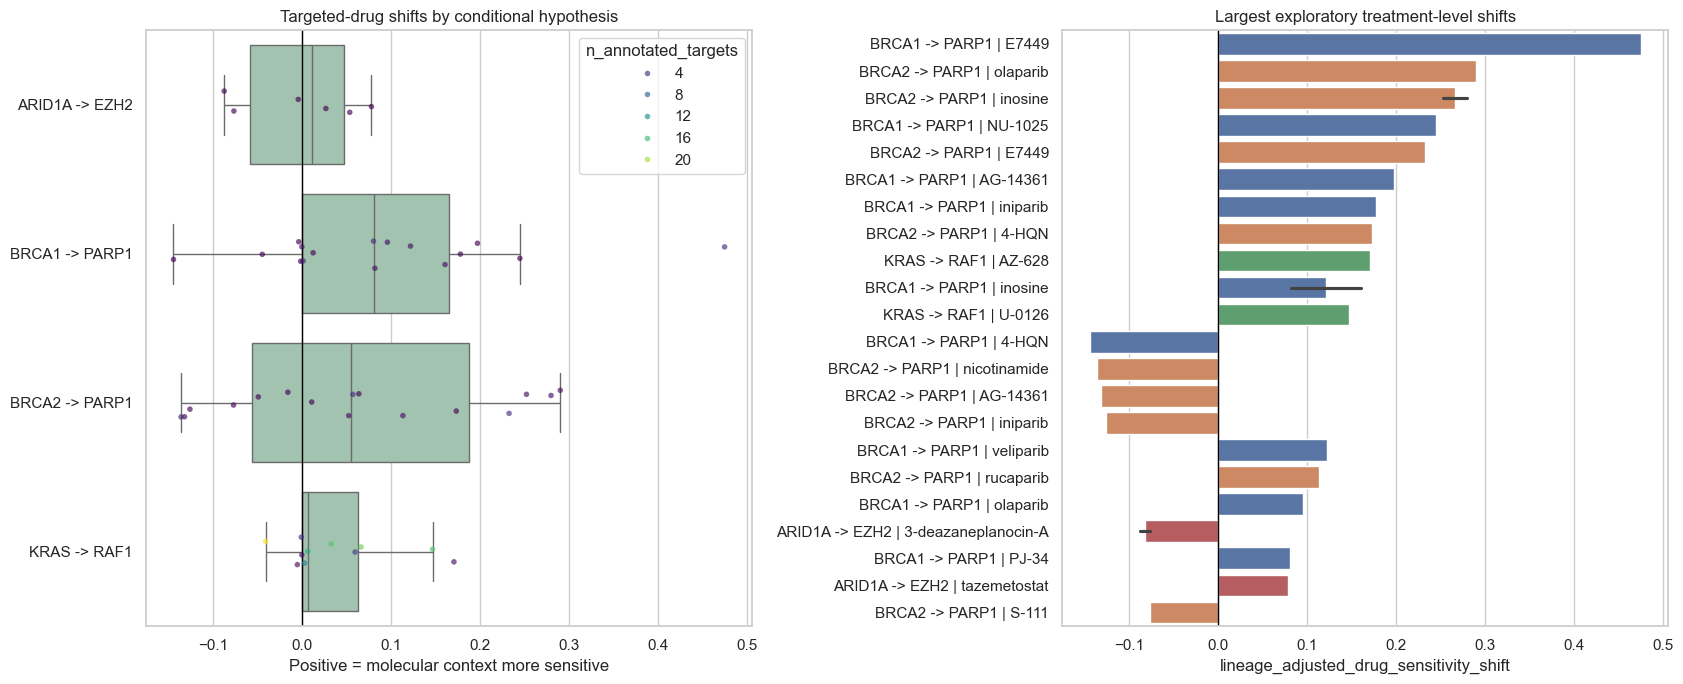

In [5]:
conditional_specs = pd.DataFrame([
    {'context_gene': 'ARID1A', 'target_gene': 'EZH2', 'context_type': 'Damaging mutation'},
    {'context_gene': 'SMARCA4', 'target_gene': 'SMARCA2', 'context_type': 'Damaging mutation'},
    {'context_gene': 'BRCA1', 'target_gene': 'PARP1', 'context_type': 'Damaging mutation'},
    {'context_gene': 'BRCA2', 'target_gene': 'PARP1', 'context_type': 'Damaging mutation'},
    {'context_gene': 'KRAS', 'target_gene': 'RAF1', 'context_type': 'Damaging mutation'},
    {'context_gene': 'MTAP', 'target_gene': 'PRMT5', 'context_type': 'Copy-number loss'},
    {'context_gene': 'MTAP', 'target_gene': 'MAT2A', 'context_type': 'Copy-number loss'},
])
conditional_specs['pair_id'] = [canonical_pair(a, b) for a, b in conditional_specs[['context_gene', 'target_gene']].itertuples(index=False, name=None)]
conditional_specs['directional_pair_id'] = conditional_specs['context_gene'] + ' -> ' + conditional_specs['target_gene']

mutations['damaging_or_driver'] = (
    mutations['has_likely_lof'].eq(1)
    | mutations['highest_vep_impact'].eq('HIGH')
    | mutations[['has_hotspot', 'has_oncogene_high_impact', 'has_tumor_suppressor_high_impact']].eq(1).any(axis=1)
)
copy_context_genes = sorted(conditional_specs.loc[conditional_specs['context_type'].eq('Copy-number loss'), 'context_gene'].unique())
copy_columns = gene_lookup.loc[copy_context_genes, 'copy_number_column'].dropna().to_dict()
copy_number = pd.read_csv(PATHS['copy_number'], usecols=['Unnamed: 0', *copy_columns.values()]).rename(
    columns={'Unnamed: 0': 'model_id', **{v: k for k, v in copy_columns.items()}}
).set_index('model_id')

prism_model_ids = set(direct_model_ids)
mutation_universe = prism_model_ids & set(master.loc[master['has_mutation_assay'].eq(1), 'model_id'])
copy_universe = prism_model_ids & set(master.loc[master['has_absolute_copy_number'].eq(1), 'model_id']) & set(copy_number.index)


def adjusted_drug_comparison(treatment_id: str, context_ids: set, reference_ids: set, minimum_context: int = 10) -> dict:
    context = sorted(set(context_ids) & prism_model_ids)
    reference = sorted(set(reference_ids) & prism_model_ids)
    selected = context + reference
    frame = pd.DataFrame({
        'drug_response': prism_response.loc[selected, treatment_id],
        'lineage': lineage_lookup.reindex(selected),
        'group': ['Context'] * len(context) + ['Reference'] * len(reference),
    }).dropna()
    raw_context = frame.loc[frame['group'].eq('Context'), 'drug_response']
    raw_reference = frame.loc[frame['group'].eq('Reference'), 'drug_response']
    keep = frame.groupby('lineage')['drug_response'].transform('size').ge(10)
    adjusted = frame.loc[keep].copy()
    adjusted['response_residual'] = adjusted['drug_response'] - adjusted.groupby('lineage')['drug_response'].transform('median')
    context_values = adjusted.loc[adjusted['group'].eq('Context'), 'response_residual']
    reference_values = adjusted.loc[adjusted['group'].eq('Reference'), 'response_residual']
    usable = len(context_values) >= minimum_context and len(reference_values) >= 10
    return {
        'raw_context_models': len(raw_context), 'raw_reference_models': len(raw_reference),
        'context_models': len(context_values), 'reference_models': len(reference_values),
        'raw_drug_sensitivity_shift': raw_reference.median() - raw_context.median() if len(raw_context) >= minimum_context and len(raw_reference) >= 10 else np.nan,
        'lineage_adjusted_drug_sensitivity_shift': reference_values.median() - context_values.median() if usable else np.nan,
    }


conditional_drug_rows = []
for spec in conditional_specs.itertuples(index=False):
    if spec.context_type == 'Damaging mutation':
        events = mutations.loc[mutations['hugo_symbol'].eq(spec.context_gene) & mutations['damaging_or_driver']]
        context_ids = set(events['model_id']) & mutation_universe
        reference_ids = mutation_universe - context_ids
    else:
        values = copy_number.loc[sorted(copy_universe), spec.context_gene].dropna()
        context_ids = set(values.index[values.le(1)])
        reference_ids = set(values.index[values.gt(1) & values.lt(4)])
    treatments = panel_target_treatments.loc[panel_target_treatments['target_gene'].eq(spec.target_gene)]
    if treatments.empty:
        conditional_drug_rows.append({
            'pair_id': spec.pair_id, 'directional_pair_id': spec.directional_pair_id,
            'context_type': spec.context_type, 'target_gene': spec.target_gene,
            'treatment_id': pd.NA, 'drug_name': pd.NA, 'n_annotated_targets': pd.NA,
            'route_state': 'no_targeted_treatment_annotation',
            'raw_context_models': len(context_ids), 'raw_reference_models': len(reference_ids),
            'context_models': 0, 'reference_models': 0,
            'raw_drug_sensitivity_shift': np.nan, 'lineage_adjusted_drug_sensitivity_shift': np.nan,
        })
        continue
    for treatment in treatments.itertuples(index=False):
        stats = adjusted_drug_comparison(treatment.treatment_id, context_ids, reference_ids)
        state = 'evaluable' if pd.notna(stats['lineage_adjusted_drug_sensitivity_shift']) else 'insufficient_groups'
        conditional_drug_rows.append({
            'pair_id': spec.pair_id, 'directional_pair_id': spec.directional_pair_id,
            'context_type': spec.context_type, 'target_gene': spec.target_gene,
            'treatment_id': treatment.treatment_id, 'drug_name': treatment.drug_name,
            'dose': treatment.dose, 'screen_id': treatment.screen_id,
            'n_annotated_targets': treatment.n_annotated_targets,
            'route_state': state, **stats,
        })

conditional_drug = pd.DataFrame(conditional_drug_rows)
conditional_drug_summary = conditional_drug.groupby(
    ['pair_id', 'directional_pair_id', 'context_type', 'target_gene'], dropna=False
).agg(
    treatment_records=('treatment_id', 'count'),
    evaluable_treatments=('lineage_adjusted_drug_sensitivity_shift', 'count'),
    median_adjusted_sensitivity_shift=('lineage_adjusted_drug_sensitivity_shift', 'median'),
    minimum_adjusted_sensitivity_shift=('lineage_adjusted_drug_sensitivity_shift', 'min'),
    maximum_adjusted_sensitivity_shift=('lineage_adjusted_drug_sensitivity_shift', 'max'),
    treatments_with_positive_shift=('lineage_adjusted_drug_sensitivity_shift', lambda s: int(s.gt(0).sum())),
    median_context_models=('context_models', 'median'),
    median_reference_models=('reference_models', 'median'),
    route_states=('route_state', lambda s: ' | '.join(sorted(set(s)))),
).reset_index()

display(conditional_drug_summary)
display(conditional_drug.loc[conditional_drug['route_state'].eq('evaluable')].sort_values('lineage_adjusted_drug_sensitivity_shift', ascending=False).head(35))

evaluable_conditional_drug = conditional_drug.loc[conditional_drug['route_state'].eq('evaluable')].copy()
fig, axes = plt.subplots(1, 2, figsize=(17, 7))
sns.boxplot(data=evaluable_conditional_drug, x='lineage_adjusted_drug_sensitivity_shift', y='directional_pair_id',
            color='#9cc9ae', showfliers=False, ax=axes[0])
sns.stripplot(data=evaluable_conditional_drug, x='lineage_adjusted_drug_sensitivity_shift', y='directional_pair_id',
              hue='n_annotated_targets', palette='viridis', size=4, alpha=0.65, ax=axes[0])
axes[0].axvline(0, color='black', linewidth=1); axes[0].set_title('Targeted-drug shifts by conditional hypothesis')
axes[0].set_xlabel('Positive = molecular context more sensitive'); axes[0].set_ylabel('')
plot_top = evaluable_conditional_drug.reindex(
    evaluable_conditional_drug['lineage_adjusted_drug_sensitivity_shift'].abs().sort_values(ascending=False).index
).head(25).copy()
plot_top['label'] = plot_top['directional_pair_id'] + ' | ' + plot_top['drug_name'].astype(str)
sns.barplot(data=plot_top, x='lineage_adjusted_drug_sensitivity_shift', y='label',
            hue='directional_pair_id', dodge=False, ax=axes[1])
axes[1].axvline(0, color='black', linewidth=1); axes[1].set_title('Largest exploratory treatment-level shifts')
axes[1].set_ylabel(''); axes[1].legend().remove()
plt.tight_layout(); plt.show()

### What this means for the project

This is chemical support for a directional hypothesis, not a final label. A positive `BRCA1 -> PARP1` treatment shift means BRCA1-context models were more sensitive to that specific PARP1-annotated compound after broad lineage differences were reduced. Different PARP inhibitors can disagree because dose, potency, transport, off-target activity, and measurement noise differ. Hypotheses without targeted treatments remain “not measured by this drug screen” and must not receive a zero feature.

## 5. Direct fusion to targeted-drug response

For each observed fusion pair, we identify PRISM treatments targeting either partner. Fusion-positive models are compared with fusion-negative models from the same represented lineages. Because these fusions are rare and the PRISM assay is historical, a minimum of three fusion-positive models is used only for exploratory display.

In [6]:
fusion_specs = pair_catalog.iloc[:4].copy()
fusion_drug_rows = []
for spec in fusion_specs.itertuples(index=False):
    fusion_positive_all = set(fusion_calls.loc[fusion_calls['fusion_pair_id'].eq(spec.pair_id), 'model_id'])
    fusion_positive = fusion_positive_all & prism_model_ids
    represented_lineages = set(lineage_lookup.reindex(sorted(fusion_positive)).dropna())
    lineage_matched_universe = set(master.loc[master['oncotree_lineage'].isin(represented_lineages), 'model_id']) & prism_model_ids
    reference_ids = lineage_matched_universe - fusion_positive
    treatments = panel_target_treatments.loc[
        panel_target_treatments['target_gene'].isin([spec.gene_a, spec.gene_b])
    ]
    treatments = treatments.groupby('treatment_id', as_index=False).agg(
        matched_target_genes=('target_gene', lambda s: ' | '.join(sorted(set(s)))),
        drug_name=('drug_name', 'first'),
        dose=('dose', 'first'),
        screen_id=('screen_id', 'first'),
        n_annotated_targets=('n_annotated_targets', 'max'),
    )
    if treatments.empty:
        fusion_drug_rows.append({
            'pair_id': spec.pair_id, 'matched_target_genes': pd.NA, 'treatment_id': pd.NA, 'drug_name': pd.NA,
            'route_state': 'no_targeted_treatment_annotation',
            'fusion_positive_models': len(fusion_positive), 'lineage_matched_reference_models': len(reference_ids),
            'lineage_adjusted_drug_sensitivity_shift': np.nan,
        })
        continue
    for treatment in treatments.itertuples(index=False):
        stats = adjusted_drug_comparison(treatment.treatment_id, fusion_positive, reference_ids, minimum_context=3)
        if len(fusion_positive) == 0:
            state = 'no_fusion_positive_prism_overlap'
        elif pd.notna(stats['lineage_adjusted_drug_sensitivity_shift']):
            state = 'evaluable_exploratory'
        else:
            state = 'insufficient_fusion_positive_models'
        fusion_drug_rows.append({
            'pair_id': spec.pair_id, 'matched_target_genes': treatment.matched_target_genes,
            'treatment_id': treatment.treatment_id, 'drug_name': treatment.drug_name,
            'dose': treatment.dose, 'screen_id': treatment.screen_id,
            'n_annotated_targets': treatment.n_annotated_targets, 'route_state': state,
            'fusion_positive_models': stats['context_models'],
            'lineage_matched_reference_models': stats['reference_models'],
            'raw_drug_sensitivity_shift': stats['raw_drug_sensitivity_shift'],
            'lineage_adjusted_drug_sensitivity_shift': stats['lineage_adjusted_drug_sensitivity_shift'],
        })

fusion_drug = pd.DataFrame(fusion_drug_rows)
fusion_drug_summary = fusion_drug.groupby('pair_id').agg(
    targeted_treatment_records=('treatment_id', 'count'),
    evaluable_treatments=('lineage_adjusted_drug_sensitivity_shift', 'count'),
    fusion_positive_models=('fusion_positive_models', 'max'),
    lineage_matched_reference_models=('lineage_matched_reference_models', 'max'),
    median_adjusted_sensitivity_shift=('lineage_adjusted_drug_sensitivity_shift', 'median'),
    minimum_adjusted_sensitivity_shift=('lineage_adjusted_drug_sensitivity_shift', 'min'),
    maximum_adjusted_sensitivity_shift=('lineage_adjusted_drug_sensitivity_shift', 'max'),
    positive_shift_treatments=('lineage_adjusted_drug_sensitivity_shift', lambda s: int(s.gt(0).sum())),
    route_states=('route_state', lambda s: ' | '.join(sorted(set(s)))),
).reset_index()
display(fusion_drug_summary)
display(fusion_drug.sort_values(['pair_id', 'lineage_adjusted_drug_sensitivity_shift'], ascending=[True, False]))

evaluable_fusion_drug = fusion_drug.loc[fusion_drug['route_state'].eq('evaluable_exploratory')].copy()
if not evaluable_fusion_drug.empty:
    plt.figure(figsize=(13, 7))
    sns.boxplot(data=evaluable_fusion_drug, x='lineage_adjusted_drug_sensitivity_shift', y='pair_id',
                color='#d99a8d', showfliers=False)
    sns.stripplot(data=evaluable_fusion_drug, x='lineage_adjusted_drug_sensitivity_shift', y='pair_id',
                  hue='matched_target_genes', size=4, alpha=0.65)
    plt.axvline(0, color='black', linewidth=1)
    plt.title('Fusion-positive versus lineage-matched targeted-drug response')
    plt.xlabel('Positive = fusion-positive models more sensitive'); plt.ylabel('')
    plt.tight_layout(); plt.show()

,pair_id,targeted_treatment_records,evaluable_treatments,fusion_positive_models,lineage_matched_reference_models,median_adjusted_sensitivity_shift,minimum_adjusted_sensitivity_shift,maximum_adjusted_sensitivity_shift,positive_shift_treatments,route_states
0,ABL1--BCR,17,0,0,0,NaN,NaN,NaN,0,no_fusion_positive_prism_overlap
1,ALK--EML4,14,0,1,99,NaN,NaN,NaN,0,insufficient_fusion_positive_models
2,ERG--TMPRSS2,0,0,0,0,NaN,NaN,NaN,0,no_targeted_treatment_annotation
3,EWSR1--FLI1,0,0,9,14,NaN,NaN,NaN,0,no_targeted_treatment_annotation


,pair_id,matched_target_genes,treatment_id,drug_name,dose,screen_id,n_annotated_targets,route_state,fusion_positive_models,lineage_matched_reference_models,raw_drug_sensitivity_shift,lineage_adjusted_drug_sensitivity_shift
0,ABL1--BCR,ABL1,BRD-A31990649-304-02-3::2.5::HTS,adenosine-triphosphate,2.500000,HTS,45.0,no_fusion_positive_prism_overlap,0,0,NaN,NaN
1,ABL1--BCR,ABL1 | BCR,BRD-A75975749-001-01-4::2.5::MTS004,bafetinib,2.500000,MTS004,3.0,no_fusion_positive_prism_overlap,0,0,NaN,NaN
2,ABL1--BCR,ABL1,BRD-K16730910-001-07-3::2.5::HTS,regorafenib,2.500000,HTS,18.0,no_fusion_positive_prism_overlap,0,0,NaN,NaN
3,ABL1--BCR,ABL1,BRD-K19540840-001-09-4::2.5::HTS,saracatinib,2.500000,HTS,4.0,no_fusion_positive_prism_overlap,0,0,NaN,NaN
4,ABL1--BCR,ABL1,BRD-K21718444-001-06-8::2.5::HTS,KW-2449,2.500000,HTS,4.0,no_fusion_positive_prism_overlap,0,0,NaN,NaN
5,ABL1--BCR,ABL1 | BCR,BRD-K27182532-001-02-3::2.5::HTS,metatinib,2.500000,HTS,2.0,no_fusion_positive_prism_overlap,0,0,NaN,NaN
6,ABL1--BCR,ABL1 | BCR,BRD-K35329391-334-01-7::2.5::HTS,GZD824,2.500000,HTS,2.0,no_fusion_positive_prism_overlap,0,0,NaN,NaN
7,ABL1--BCR,ABL1 | BCR,BRD-K44227013-001-06-4::2.5::HTS,ponatinib,2.500000,HTS,15.0,no_fusion_positive_prism_overlap,0,0,NaN,NaN
8,ABL1--BCR,ABL1,BRD-K49328571-001-15-0::2.5::HTS,dasatinib,2.500000,HTS,16.0,no_fusion_positive_prism_overlap,0,0,NaN,NaN
9,ABL1--BCR,ABL1,BRD-K59831625-001-01-6::2.5::HTS,LDN-212854,2.500000,HTS,3.0,no_fusion_positive_prism_overlap,0,0,NaN,NaN


### What this means for the project

Fusion-to-drug analysis is attractive because a fusion can create a directly targetable driver. However, the overlap between rare fusion-positive models and historical PRISM screening can be very small. A positive shift is therefore a lead for inspection, not validation by itself. The dashboard must show the fusion-positive count, matched reference count, exact compound, target annotation, dose, and release mismatch.

## 6. TCGA tumour-cohort coverage

TCGA patients cannot be joined to cell lines. Instead, we use an explicit project-to-lineage crosswalk to identify which patient cohorts could later test whether molecular relationships seen in cell lines also occur in tumours. The crosswalk is deliberately visible and only covers projects with a reasonable broad-lineage mapping.

,tcga_project_id,tcga_project_name,patients,primary_sites,vital_status_available_pct,stage_available_pct,age_available_pct,mapped_oncotree_lineage
2,TCGA-BRCA,Breast Invasive Carcinoma,1098,1,99.908925,0.0,0.0,Breast
8,TCGA-GBM,Glioblastoma Multiforme,617,1,97.244733,0.0,0.0,CNS/Brain
19,TCGA-OV,Ovarian Serous Cystadenocarcinoma,608,2,96.546053,0.0,0.0,Ovary/Fallopian Tube
16,TCGA-LUAD,Lung Adenocarcinoma,585,1,89.230769,0.0,0.0,Lung
30,TCGA-UCEC,Uterine Corpus Endometrial Carcinoma,560,2,97.857143,0.0,0.0,Uterus
11,TCGA-KIRC,Kidney Renal Clear Cell Carcinoma,537,1,100.000000,0.0,0.0,Kidney
9,TCGA-HNSC,Head and Neck Squamous Cell Carcinoma,528,13,100.000000,0.0,0.0,Head and Neck
14,TCGA-LGG,Brain Lower Grade Glioma,516,1,100.000000,0.0,0.0,CNS/Brain
28,TCGA-THCA,Thyroid Carcinoma,507,1,100.000000,0.0,0.0,Thyroid
17,TCGA-LUSC,Lung Squamous Cell Carcinoma,504,1,100.000000,0.0,0.0,Lung


,mapped_oncotree_lineage,depmap_models,crispr_models,fusion_assayed_models,tcga_patients,tcga_projects,project_ids
18,Lung,260,126,214,1089.0,2.0,TCGA-LUAD | TCGA-LUSC
19,Lymphoid,260,93,186,58.0,1.0,TCGA-DLBC
29,Skin,149,74,120,470.0,1.0,TCGA-SKCM
8,CNS/Brain,125,90,100,1133.0,2.0,TCGA-GBM | TCGA-LGG
11,Esophagus/Stomach,103,69,77,628.0,2.0,TCGA-ESCA | TCGA-STAD
6,Bowel,99,63,86,633.0,2.0,TCGA-COAD | TCGA-READ
7,Breast,96,53,70,1098.0,1.0,TCGA-BRCA
15,Head and Neck,95,77,74,528.0,1.0,TCGA-HNSC
5,Bone,90,46,55,NaN,NaN,NaN
21,Myeloid,88,42,74,200.0,1.0,TCGA-LAML


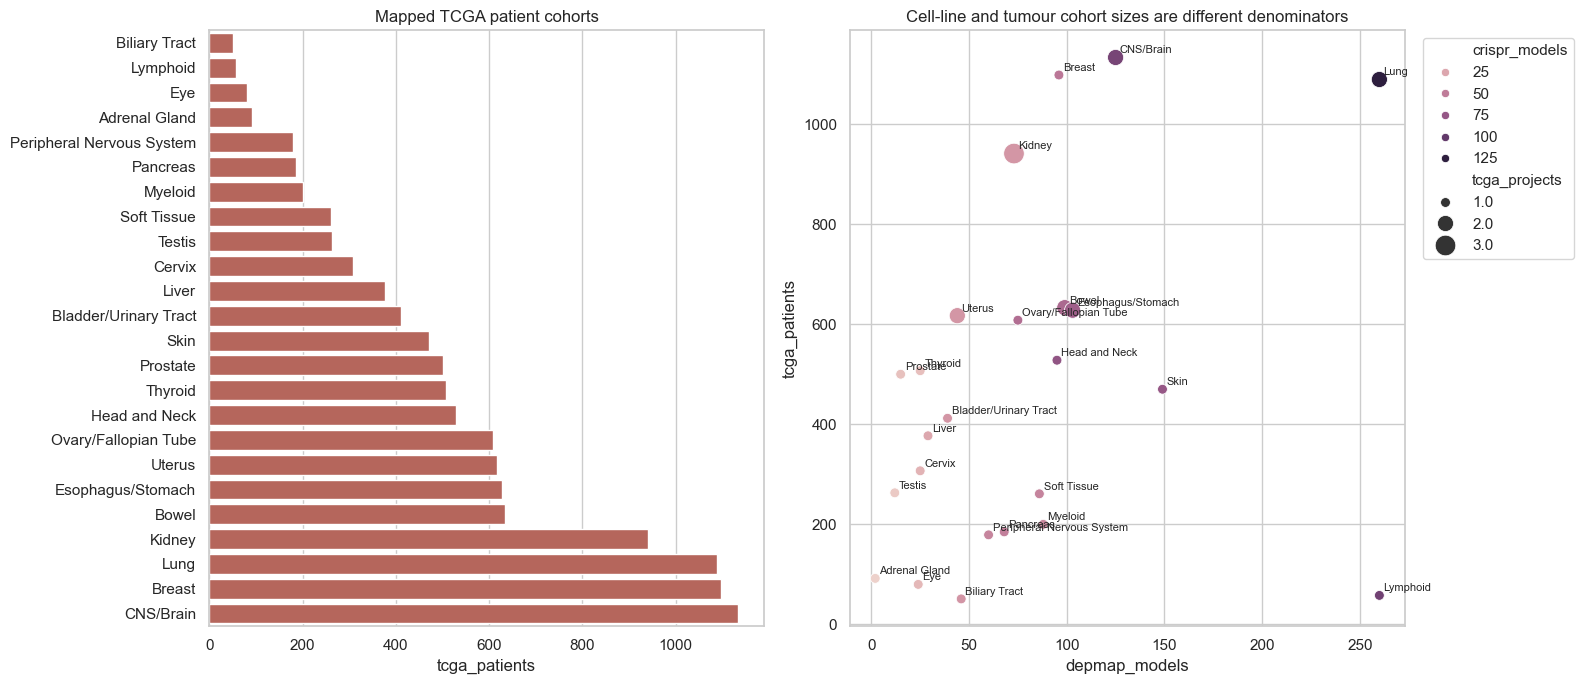

In [7]:
tcga_project_to_lineage = {
    'TCGA-BRCA': 'Breast', 'TCGA-LUAD': 'Lung', 'TCGA-LUSC': 'Lung',
    'TCGA-COAD': 'Bowel', 'TCGA-READ': 'Bowel', 'TCGA-PRAD': 'Prostate',
    'TCGA-LAML': 'Myeloid', 'TCGA-DLBC': 'Lymphoid', 'TCGA-SARC': 'Soft Tissue',
    'TCGA-SKCM': 'Skin', 'TCGA-OV': 'Ovary/Fallopian Tube', 'TCGA-UCEC': 'Uterus',
    'TCGA-UCS': 'Uterus', 'TCGA-GBM': 'CNS/Brain', 'TCGA-LGG': 'CNS/Brain',
    'TCGA-KIRC': 'Kidney', 'TCGA-KIRP': 'Kidney', 'TCGA-KICH': 'Kidney',
    'TCGA-STAD': 'Esophagus/Stomach', 'TCGA-ESCA': 'Esophagus/Stomach',
    'TCGA-PAAD': 'Pancreas', 'TCGA-LIHC': 'Liver', 'TCGA-CHOL': 'Biliary Tract',
    'TCGA-BLCA': 'Bladder/Urinary Tract', 'TCGA-CESC': 'Cervix',
    'TCGA-THCA': 'Thyroid', 'TCGA-HNSC': 'Head and Neck',
    'TCGA-PCPG': 'Peripheral Nervous System', 'TCGA-TGCT': 'Testis',
    'TCGA-UVM': 'Eye', 'TCGA-ACC': 'Adrenal Gland',
}
tcga['mapped_oncotree_lineage'] = tcga['tcga_project_id'].map(tcga_project_to_lineage)
tcga_project_coverage = tcga.groupby(['tcga_project_id', 'tcga_project_name'], as_index=False).agg(
    patients=('patient_id', 'nunique'),
    primary_sites=('primary_site', 'nunique'),
    vital_status_available_pct=('vital_status', lambda s: 100 * s.notna().mean()),
    stage_available_pct=('tumor_stage', lambda s: 100 * s.notna().mean()),
    age_available_pct=('age_at_diagnosis', lambda s: 100 * s.notna().mean()),
)
tcga_project_coverage['mapped_oncotree_lineage'] = tcga_project_coverage['tcga_project_id'].map(tcga_project_to_lineage)
display(tcga_project_coverage.sort_values('patients', ascending=False))

lineage_cohort_coverage = tcga.loc[tcga['mapped_oncotree_lineage'].notna()].groupby('mapped_oncotree_lineage').agg(
    tcga_patients=('patient_id', 'nunique'),
    tcga_projects=('tcga_project_id', 'nunique'),
    project_ids=('tcga_project_id', lambda s: ' | '.join(sorted(set(s)))),
).reset_index()
depmap_lineage_coverage = master.groupby('oncotree_lineage').agg(
    depmap_models=('model_id', 'nunique'),
    crispr_models=('has_crispr_gene_effect', 'sum'),
    fusion_assayed_models=('has_fusion_assay', 'sum'),
).reset_index().rename(columns={'oncotree_lineage': 'mapped_oncotree_lineage'})
cell_tumour_cohort_map = depmap_lineage_coverage.merge(
    lineage_cohort_coverage, on='mapped_oncotree_lineage', how='left', validate='one_to_one'
)
display(cell_tumour_cohort_map.sort_values('depmap_models', ascending=False))

plot_lineages = cell_tumour_cohort_map.loc[cell_tumour_cohort_map['tcga_patients'].notna()].copy()
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
sns.barplot(data=plot_lineages.sort_values('tcga_patients'), x='tcga_patients', y='mapped_oncotree_lineage',
            color='#c45b4d', ax=axes[0])
axes[0].set_title('Mapped TCGA patient cohorts'); axes[0].set_ylabel('')
sns.scatterplot(data=plot_lineages, x='depmap_models', y='tcga_patients', size='tcga_projects',
                hue='crispr_models', sizes=(50, 220), ax=axes[1])
for row in plot_lineages.itertuples(index=False):
    axes[1].annotate(row.mapped_oncotree_lineage, (row.depmap_models, row.tcga_patients),
                     xytext=(3, 3), textcoords='offset points', fontsize=8)
axes[1].set_title('Cell-line and tumour cohort sizes are different denominators')
axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout(); plt.show()

### What this means for the project

TCGA provides large patient cohorts for many lineages represented in DepMap, but cohort size alone is not tumour validation. The explicit crosswalk only identifies where validation could be attempted after molecular data are added. A breast cell line and a TCGA breast tumour are never the same biological sample, so comparisons must be made at cohort level with tumour subtype and assay definitions visible.

## 7. Tumour molecular-layer readiness

The local TCGA table contains patient identifiers and clinical fields. It does not contain gene-level mutation, copy-number, RNA, or fusion measurements. This section records that limitation directly and specifies the grain needed for future tumour validation.

In [8]:
tcga_layer_audit = pd.DataFrame([
    {'tumour_layer': 'Patient and project identity', 'present_locally': True, 'local_grain': 'one patient per row', 'possible_now': 'cohort selection and size audit'},
    {'tumour_layer': 'Clinical outcome/context', 'present_locally': True, 'local_grain': 'patient clinical fields with variable missingness', 'possible_now': 'describe cohorts; not validate molecular pairs'},
    {'tumour_layer': 'Somatic mutation', 'present_locally': False, 'local_grain': 'not present', 'possible_now': 'cannot test Gene A mutation prevalence'},
    {'tumour_layer': 'Gene-level copy number', 'present_locally': False, 'local_grain': 'not present', 'possible_now': 'cannot test Gene A loss or gain'},
    {'tumour_layer': 'Gene expression', 'present_locally': False, 'local_grain': 'not present', 'possible_now': 'cannot test RNA-high context or co-expression'},
    {'tumour_layer': 'Fusion calls', 'present_locally': False, 'local_grain': 'not present', 'possible_now': 'cannot test fusion recurrence in tumours'},
    {'tumour_layer': 'Proteomics', 'present_locally': False, 'local_grain': 'not present', 'possible_now': 'cannot test protein-level transfer'},
])
display(tcga_layer_audit)

tumour_validation_contract = pd.DataFrame([
    {'validation_question': 'Does a direct fusion occur in human tumours?', 'required_table_grain': 'tumour sample x canonical fusion pair', 'required_fields': 'sample, project/subtype, both genes, breakpoints, support, caller/version'},
    {'validation_question': 'Does Gene A context occur in human tumours?', 'required_table_grain': 'tumour sample x gene', 'required_fields': 'sample, gene ID, mutation/CN/RNA state, assay/version'},
    {'validation_question': 'Are Gene A and Gene B linked in the same tumour?', 'required_table_grain': 'tumour sample x pair', 'required_fields': 'sample, both measurements, subtype, purity/covariates'},
    {'validation_question': 'Does the pair associate with patient outcome?', 'required_table_grain': 'patient/sample x pair feature', 'required_fields': 'feature, time-to-event, censoring, clinical covariates, cohort split'},
])
display(tumour_validation_contract)

validation_status = pd.DataFrame([
    {'validation_layer': 'Drug response matrix', 'state': 'available for exploratory external support', 'main_limitation': 'historical single-dose primary screen; release mismatch and multi-target compounds'},
    {'validation_layer': 'Drug target annotations', 'state': 'partially available', 'main_limitation': '1,222 treatment records lack target annotation and annotations do not prove selectivity'},
    {'validation_layer': 'Tumour cohort context', 'state': 'available', 'main_limitation': 'cohort mapping is broad and not a sample identity join'},
    {'validation_layer': 'Tumour molecular validation', 'state': 'not currently possible', 'main_limitation': 'local TCGA data contain no mutation, CN, RNA, fusion, or protein measurements'},
])
display(validation_status)

,tumour_layer,present_locally,local_grain,possible_now
0,Patient and project identity,True,one patient per row,cohort selection and size audit
1,Clinical outcome/context,True,patient clinical fields with variable missingness,describe cohorts; not validate molecular pairs
2,Somatic mutation,False,not present,cannot test Gene A mutation prevalence
3,Gene-level copy number,False,not present,cannot test Gene A loss or gain
4,Gene expression,False,not present,cannot test RNA-high context or co-expression
5,Fusion calls,False,not present,cannot test fusion recurrence in tumours
6,Proteomics,False,not present,cannot test protein-level transfer


,validation_question,required_table_grain,required_fields
0,Does a direct fusion occur in human tumours?,tumour sample x canonical fusion pair,"sample, project/subtype, both genes, breakpoin..."
1,Does Gene A context occur in human tumours?,tumour sample x gene,"sample, gene ID, mutation/CN/RNA state, assay/..."
2,Are Gene A and Gene B linked in the same tumour?,tumour sample x pair,"sample, both measurements, subtype, purity/cov..."
3,Does the pair associate with patient outcome?,patient/sample x pair feature,"feature, time-to-event, censoring, clinical co..."


,validation_layer,state,main_limitation
0,Drug response matrix,available for exploratory external support,historical single-dose primary screen; release...
1,Drug target annotations,partially available,"1,222 treatment records lack target annotation..."
2,Tumour cohort context,available,cohort mapping is broad and not a sample ident...
3,Tumour molecular validation,not currently possible,"local TCGA data contain no mutation, CN, RNA, ..."


### What this means for the project

Drug response can now provide external exploratory support for some routes, with substantial assay and target-specific caveats. Tumour validation cannot yet be calculated. The correct next tumour-data task is to add molecular TCGA layers with stable gene and sample identifiers, then audit sample overlap within each project before testing pair prevalence or outcome associations.

## 8. Decisions carried forward

In [9]:
decisions = pd.DataFrame([
    {'decision': 'PRISM grain', 'rule': 'Use direct model rows x exact treatment columns; document the incorrect local JSON orientation.'},
    {'decision': 'Release provenance', 'rule': 'Treat PRISM 19Q4 as historical external support, not a release-matched master-table feature.'},
    {'decision': 'Response direction', 'rule': 'Lower PRISM LFC means more sensitivity; engineered positive shifts mean the context group is more sensitive.'},
    {'decision': 'Target attribution', 'rule': 'Keep exact target list and multi-target count beside every chemical result.'},
    {'decision': 'Drug aggregation', 'rule': 'Retain treatment-level results; summaries describe a set of non-independent treatments.'},
    {'decision': 'Conditional drug evidence', 'rule': 'Keep Gene A direction, molecular context, target Gene B, and both group sizes.'},
    {'decision': 'Fusion drug evidence', 'rule': 'Use lineage-matched references and label groups below 10 fusion-positive models exploratory.'},
    {'decision': 'TCGA joins', 'rule': 'Never join patients to cell lines; use an explicit project-to-lineage cohort crosswalk.'},
    {'decision': 'Tumour validation gate', 'rule': 'Do not claim tumour validation until gene-level molecular layers are present and sample overlap is audited.'},
    {'decision': 'Modelling', 'rule': 'No route weights, rankings, labels, or probabilities are learned in this notebook.'},
])
display(decisions)

assert prism_response.index.is_unique
assert prism_treatments['column_name'].is_unique
assert set(prism_response.columns) == set(prism_treatments['column_name'])
assert set(direct_model_ids).issubset(master_ids)
assert genetic_drug_concordance['shared_crispr_prism_models'].le(len(shared_crispr_prism_ids)).all()
assert conditional_drug.loc[conditional_drug['lineage_adjusted_drug_sensitivity_shift'].notna(), 'context_models'].ge(10).all()
assert conditional_drug.loc[conditional_drug['lineage_adjusted_drug_sensitivity_shift'].notna(), 'reference_models'].ge(10).all()
assert not tcga_layer_audit.loc[tcga_layer_audit['tumour_layer'].isin(['Somatic mutation', 'Gene-level copy number', 'Gene expression', 'Fusion calls']), 'present_locally'].any()

print('Validation checks passed.')
print(f'Direct PRISM-to-model matches: {len(direct_model_ids):,}')
print(f'Shared PRISM and CRISPR models: {len(shared_crispr_prism_ids):,}')
print(f'Panel-target treatment records: {len(panel_target_treatments):,}')
print(f'Genetic-to-chemical comparisons: {len(genetic_drug_concordance):,}')
print(f'Evaluable conditional targeted-drug comparisons: {conditional_drug.lineage_adjusted_drug_sensitivity_shift.notna().sum():,}')
print(f'Evaluable fusion targeted-drug comparisons: {fusion_drug.lineage_adjusted_drug_sensitivity_shift.notna().sum():,}')
print(f'TCGA patients available for cohort planning: {tcga.patient_id.nunique():,}')
print('TCGA molecular validation available: No')

,decision,rule
0,PRISM grain,Use direct model rows x exact treatment column...
1,Release provenance,Treat PRISM 19Q4 as historical external suppor...
2,Response direction,Lower PRISM LFC means more sensitivity; engine...
3,Target attribution,Keep exact target list and multi-target count ...
4,Drug aggregation,Retain treatment-level results; summaries desc...
5,Conditional drug evidence,"Keep Gene A direction, molecular context, targ..."
6,Fusion drug evidence,Use lineage-matched references and label group...
7,TCGA joins,Never join patients to cell lines; use an expl...
8,Tumour validation gate,Do not claim tumour validation until gene-leve...
9,Modelling,"No route weights, rankings, labels, or probabi..."


Validation checks passed.
Direct PRISM-to-model matches: 568
Shared PRISM and CRISPR models: 469
Panel-target treatment records: 121
Genetic-to-chemical comparisons: 121
Evaluable conditional targeted-drug comparisons: 49
Evaluable fusion targeted-drug comparisons: 0
TCGA patients available for cohort planning: 11,428
TCGA molecular validation available: No


### What this means for the project

This notebook establishes where external validation is already feasible and where it is not. PRISM supports treatment-level exploratory checks for druggable targets, while TCGA currently supports only cohort planning. The next step should be to review the drug-response examples biologically and acquire TCGA molecular layers before designing any final validation label or predictive model.